# Predicting Bank Term Deposit Subscription Using AdaBoost

**A complete, end-to-end binary classification project built on the UCI Bank Marketing dataset.**

This notebook builds, evaluates, tunes, and interprets an **AdaBoost** classifier that predicts
whether a bank customer will subscribe to a term deposit after a telemarketing campaign. Along the
way we build baseline models, explain *why* AdaBoost works the way it does, and connect every
modelling decision back to a business question a bank could actually ask.

## 1. Introduction & Problem Definition

### 1.1 The business problem

A Portuguese retail bank ran a series of **phone-based direct-marketing campaigns** offering
customers a **term deposit** (a fixed-term savings product). Each campaign call is not free — it
costs staff time, and repeated calls can irritate customers. The bank wants to know, *before*
picking up the phone, how likely a given customer is to say yes.

### 1.2 The machine-learning problem

We are given a table of customer attributes (demographics, financial status) and campaign
attributes (how they were contacted, how many times, the outcome of the previous campaign), plus
a handful of macro-economic indicators recorded at the time of the call. The target column `y`
records whether the customer subscribed (`yes`) or not (`no`).

This is a **binary classification** problem:

- **Input (X):** customer + campaign + economic features
- **Output (y):** `1` if the customer subscribed, `0` otherwise

### 1.3 Why AdaBoost?

AdaBoost (**Ada**ptive **Boost**ing) is a natural fit here because:

- The feature set is a mix of numeric and categorical variables with non-linear relationships to
  the target (e.g. very young and very old customers subscribe at different rates than
  middle-aged customers) — a linear model alone would miss this.
- AdaBoost builds an ensemble of very simple **decision stumps**, which is naturally robust to
  irrelevant features and does not require heavy feature scaling.
- Boosting explicitly **re-weights the customers the model gets wrong**, which is valuable here
  because the class we care most about (`subscribed`) is the minority class — boosting keeps
  forcing the ensemble to pay attention to it.
- It is fast to train, easy to interpret via feature importances, and serves as a strong,
  well-understood baseline before reaching for heavier gradient-boosting libraries.

### 1.4 Roadmap

We will: explore the data → preprocess it safely (no leakage) → fit baseline models
(Logistic Regression, Decision Tree, Random Forest) → explain and fit AdaBoost → evaluate it
thoroughly → tune it → compare everything → interpret the features → analyse errors → and finish
with a business-facing recommendation.

## 0. Setup

We only use the standard data-science stack: NumPy, Pandas, Matplotlib, Seaborn and
Scikit-learn.

In [1]:
%pip install --upgrade numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, RocCurveDisplay, roc_curve
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 50)

## 2. Dataset Loading

**Dataset:** UCI Machine Learning Repository — *Bank Marketing* dataset (Moro, Cortez & Rita,
2014), the full version with 41,188 customer records and 20 candidate input features plus the
target `y`.

We load it directly from a CSV mirror of the original UCI file. The file is **semicolon-delimited**,
which is a common gotcha with this dataset.

In [3]:
DATA_PATH = "bank-full.csv"  # semicolon-separated, as distributed by UCI
df = pd.read_csv(DATA_PATH, sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [5]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 45,211
Columns: 17


In [6]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [8]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [10]:
df.describe(include=["object", "str"]).T

,count,unique,top,freq
job,45211,12,blue-collar,9732
marital,45211,3,married,27214
education,45211,4,secondary,23202
default,45211,2,no,44396
housing,45211,2,yes,25130
loan,45211,2,no,37967
contact,45211,3,cellular,29285
month,45211,12,may,13766
poutcome,45211,4,unknown,36959
y,45211,2,no,39922


In [11]:
missing = df.isnull().sum()
missing[missing > 0] if missing.sum() > 0 else "No missing values found."

'No missing values found.'

In [12]:
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates}")
if n_duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Dropped duplicates. New shape: {df.shape}")

Duplicate rows: 0


**Reading the output.** The dataset has no true `NaN` values, but several categorical columns
(`job`, `education`, `default`, `housing`, `loan`) contain an explicit `"unknown"` category —
this is a form of missingness that we will treat as its own category rather than drop, since
"declined to answer" can itself be informative. There are a small number of exact duplicate rows,
which we remove since they add no new information and could bias the model toward those repeated
records. `pdays = 999` is a sentinel value meaning "never previously contacted", not a real day
count — we will engineer this into something more useful during preprocessing.

## 3. Exploratory Data Analysis

### 3.1 Target variable

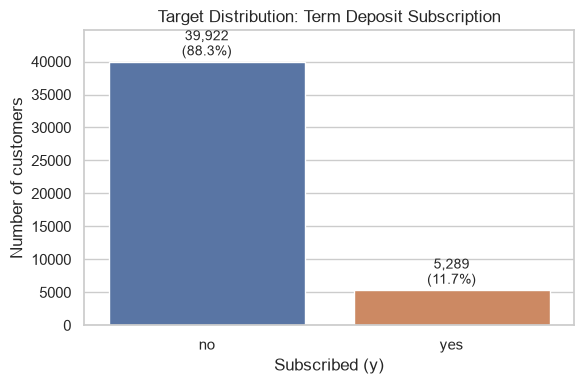

y
no     39922
yes     5289
Name: count, dtype: int64

In [17]:
target_counts = df["y"].value_counts()
target_pct = df["y"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(
    x="y",
    data=df,
    order=["no", "yes"],
    hue="y",
    palette=["#4C72B0", "#DD8452"],
    legend=False,
    ax=ax
)

ax.set_title("Target Distribution: Term Deposit Subscription")
ax.set_xlabel("Subscribed (y)")
ax.set_ylabel("Number of customers")

for i, category in enumerate(["no", "yes"]):
    v = target_counts[category]
    pct = target_pct[category]

    ax.text(
        i,
        v + target_counts.max() * 0.01,
        f"{v:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Give labels some room above the bars
ax.set_ylim(0, target_counts.max() * 1.12)

plt.tight_layout()
plt.show()

target_counts

**Finding.** Only around **11%** of customers subscribed. This is a clearly **imbalanced**
classification problem. Accuracy alone would be a misleading metric — a model that always
predicts "no" would already score roughly 89% accuracy while being completely useless to the
bank. We will lean on **precision, recall, F1 and ROC-AUC** instead, and will use **stratified**
splitting and cross-validation throughout so that both classes are represented proportionally in
every fold.

### 3.2 Numerical variables

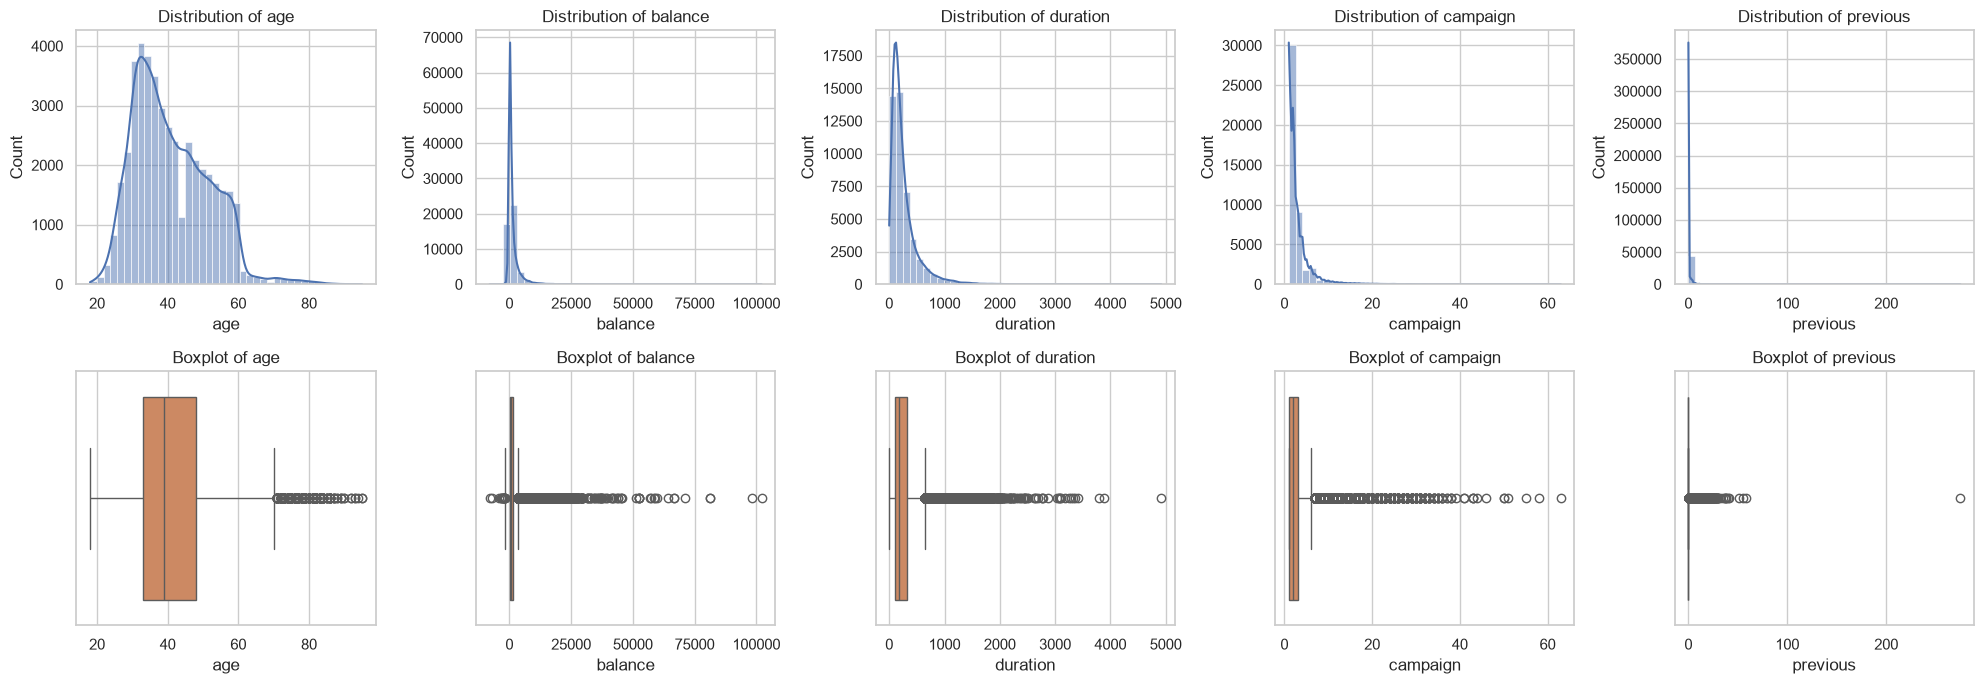

In [18]:
num_cols = ["age", "balance" if "balance" in df.columns else "duration", "duration", "campaign", "previous"]
num_cols = [c for c in ["age", "balance", "duration", "campaign", "previous"] if c in df.columns]

fig, axes = plt.subplots(2, len(num_cols), figsize=(4 * len(num_cols), 7))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=40, ax=axes[0, i], color="#4C72B0", kde=True)
    axes[0, i].set_title(f"Distribution of {col}")
    sns.boxplot(x=df[col], ax=axes[1, i], color="#DD8452")
    axes[1, i].set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

**Finding.** `age` is roughly bell-shaped with a right tail of older customers. `duration`
(last call length) and `campaign` (number of contacts) are heavily right-skewed with visible
outliers — a handful of customers were called many times, and some calls lasted a very long time.
`previous` is dominated by zero (most customers were never contacted before this campaign).
Tree-based models such as AdaBoost, Random Forest and Decision Trees are **not sensitive to
monotonic outliers or skew** (they split on thresholds, not distances), so we will not clip or
transform these features — we only need to watch out for skew when interpreting Logistic
Regression coefficients.

**Important note on `duration`:** the UCI documentation warns that call `duration` is only known
*after* the call ends, so a model trained with it cannot be used to decide whether to call someone
in the first place — it would leak the outcome. We keep it in this notebook for benchmarking
purposes (as the original dataset authors did) but flag this clearly as a limitation in
Section 15.

### 3.3 Categorical variables

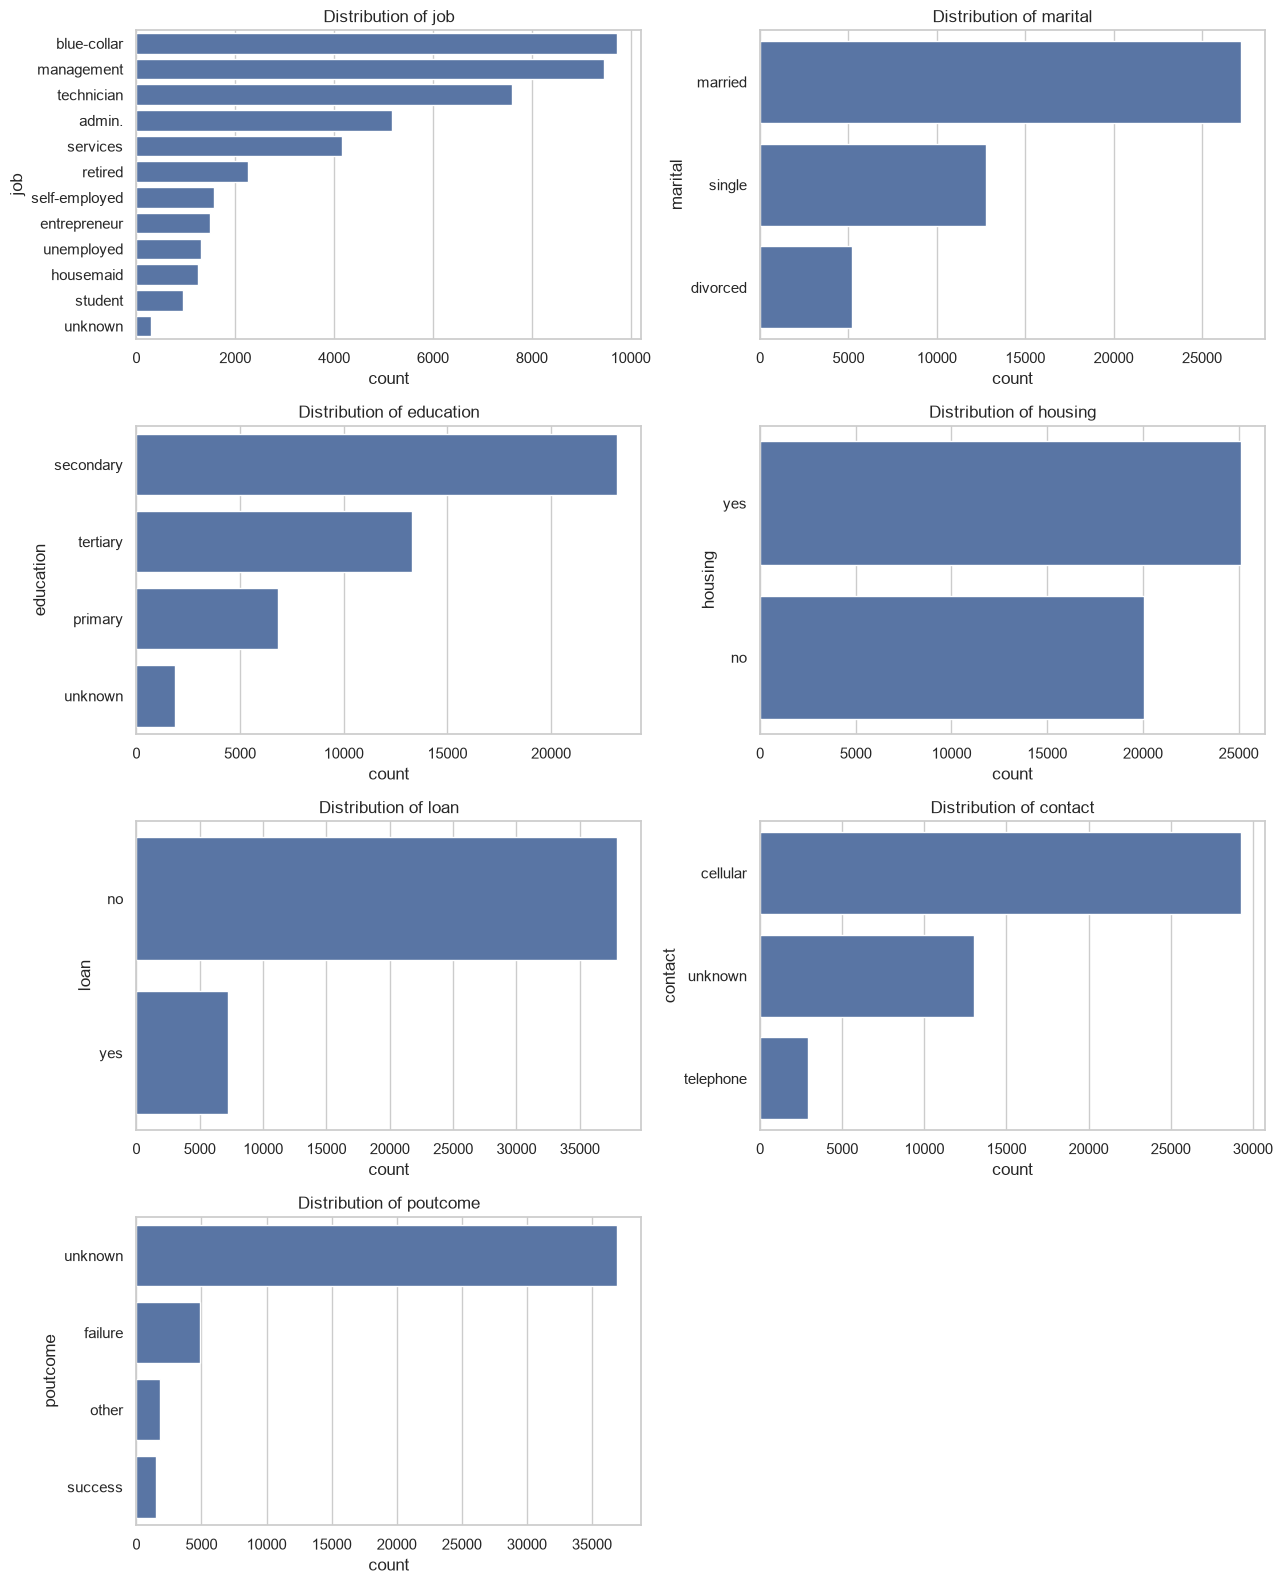

In [19]:
cat_cols = [c for c in ["job", "marital", "education", "housing", "loan", "contact", "poutcome"] if c in df.columns]

fig, axes = plt.subplots(4, 2, figsize=(13, 16))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Distribution of {col}")
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

**Finding.** `job` is dominated by "admin.", "blue-collar" and "technician". Most customers are
married with a secondary education. Around half hold a housing loan while very few have a
personal loan. `poutcome` (outcome of the *previous* campaign) is mostly "nonexistent", confirming
that most customers are being contacted for the first time. `contact` is mostly "cellular",
reflecting the campaign's shift toward mobile phones over the study period.

### 3.4 Relationship with the target

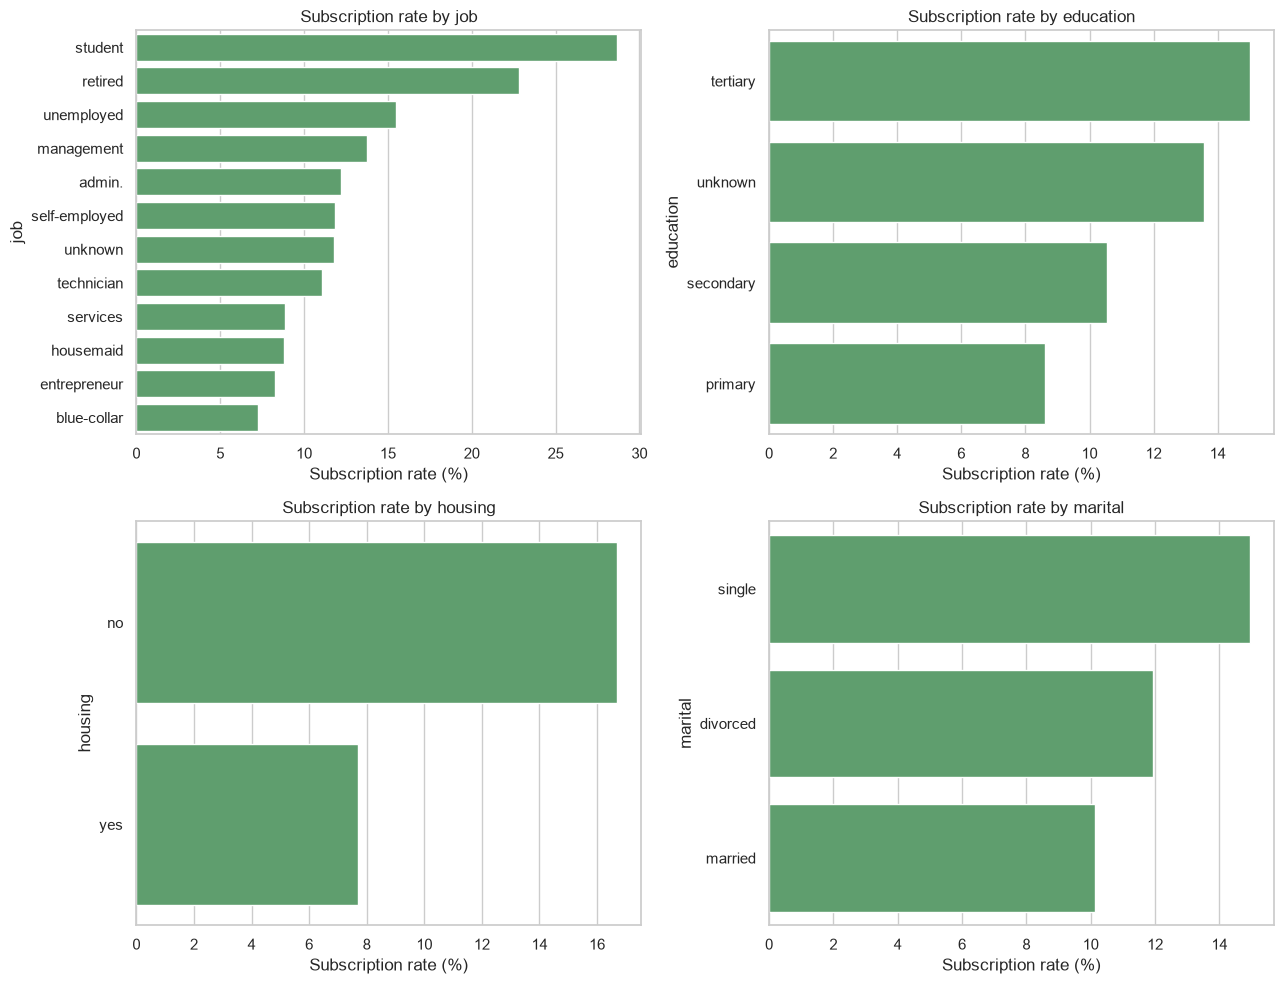

In [20]:
def subscription_rate_by(col, top_n=None):
    rates = df.groupby(col)["y"].apply(lambda s: (s == "yes").mean() * 100).sort_values(ascending=False)
    if top_n:
        rates = rates.head(top_n)
    return rates

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, col in zip(axes.flatten(), ["job", "education", "housing", "marital"]):
    rates = subscription_rate_by(col)
    sns.barplot(x=rates.values, y=rates.index, ax=ax, color="#55A868")
    ax.set_xlabel("Subscription rate (%)")
    ax.set_title(f"Subscription rate by {col}")

plt.tight_layout()
plt.show()

**Finding.** Subscription rate varies noticeably across groups: students and retirees subscribe
at a much higher rate than blue-collar or entrepreneur customers, customers with a tertiary
education subscribe more than those with only a primary education, and customers **without** a
housing loan subscribe more than those with one. These are exactly the kinds of interactions a
tree-based ensemble like AdaBoost can pick up automatically, without us having to hand-engineer
interaction terms.

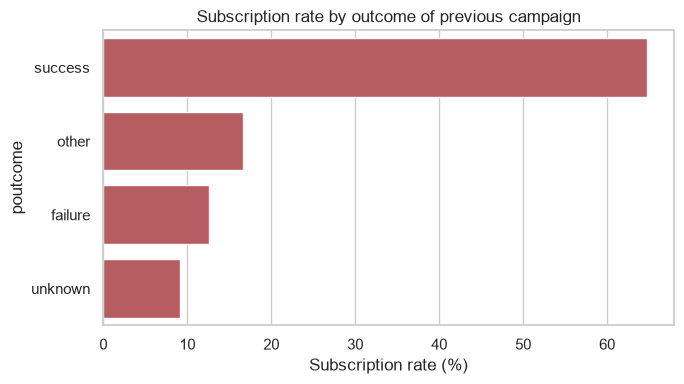

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=subscription_rate_by("poutcome").values, y=subscription_rate_by("poutcome").index,
            ax=ax, color="#C44E52")
ax.set_xlabel("Subscription rate (%)")
ax.set_title("Subscription rate by outcome of previous campaign")
plt.tight_layout()
plt.show()

**Finding.** Customers whose previous campaign outcome was a "success" subscribe again at a very
high rate. This is one of the strongest signals in the dataset and, unlike `duration`, it is
known **before** the call is made — a genuinely actionable feature for targeting.

## 4. Data Preprocessing

### 4.1 Target encoding

In [22]:
df["y"] = df["y"].map({"yes": 1, "no": 0})
df["y"].value_counts()

y
0    39922
1     5289
Name: count, dtype: int64

### 4.2 Why categorical variables must be encoded

Scikit-learn's estimators operate on numerical arrays — they cannot interpret strings like
`"married"` or `"technician"` directly. We use **one-hot encoding**, which creates a separate
binary (0/1) column per category. This is preferred over ordinal (integer) encoding for these
features because categories like `job` or `contact` have **no natural order**; assigning them
arbitrary integers would imply a false ranking that a linear model in particular could
misinterpret as meaningful magnitude.

### 4.3 Do we need to scale numeric features?

**Decision Tree, Random Forest and AdaBoost (with tree stumps) do not need feature scaling** —
they split on raw thresholds, so the scale of a feature does not affect the split it finds.
**Logistic Regression, however, is scale-sensitive** because it optimises a weighted sum of
features with gradient descent; unscaled features can slow or destabilise convergence and distort
the regularisation penalty. To keep a single, fair pipeline for every model, we standardise
numeric features for all of them — it does not hurt the tree-based models and it is necessary for
Logistic Regression.

### 4.4 Feature set

We drop `duration` from the *modelling* feature set to avoid leakage (see the note in Section 3),
keeping the rest of the customer, campaign and economic-context features. We also engineer a
`was_previously_contacted` flag from `pdays`, since 999 is a sentinel rather than a real value.

In [24]:
LEAK_COLS = [c for c in ["duration"] if c in df.columns]

work_df = df.drop(columns=LEAK_COLS).copy()

if "pdays" in work_df.columns:
    work_df["was_previously_contacted"] = (work_df["pdays"] != 999).astype(int)
    work_df["pdays"] = work_df["pdays"].replace(999, -1)

TARGET = "y"

X = work_df.drop(columns=[TARGET])
y = work_df[TARGET]

# Identify categorical and numerical features
categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numeric_features = X.select_dtypes(
    exclude=["object", "string"]
).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numeric features: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'was_previously_contacted']


### 4.5 Train-test split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Train size: {X_train.shape[0]:,} rows")
print(f"Test size:  {X_test.shape[0]:,} rows")
print("Train subscription rate:", y_train.mean().round(4))
print("Test  subscription rate:", y_test.mean().round(4))

Train size: 36,168 rows
Test size:  9,043 rows
Train subscription rate: 0.117
Test  subscription rate: 0.117


We stratify on `y` so that the ~11% minority class is represented proportionally in both splits,
and fix `random_state=42` so the split — and every result downstream — is reproducible.

### 4.6 Preprocessing pipeline

We build the encoder/scaler inside a `ColumnTransformer`, and will fit it **only on the training
fold** for every model (`Pipeline.fit` does this automatically), so no information from the test
set ever leaks into preprocessing statistics.

In [26]:
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 5. Baseline Models

Before reaching for AdaBoost, we establish three baselines: **Logistic Regression** (a simple
linear benchmark), a single **Decision Tree** (an unboosted weak-learner-sized model for
comparison), and a **Random Forest** (a strong bagging ensemble). Each is wrapped in the same
`Pipeline` (preprocessing + model) so comparisons are apples-to-apples.

In [27]:
def build_pipeline(estimator):
    return Pipeline(steps=[("preprocess", preprocessor), ("model", estimator)])

def evaluate_model(name, pipeline, X_test, y_test, results_store):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    results_store[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }
    return y_pred, y_proba

results = {}

In [28]:
log_reg = build_pipeline(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
log_reg.fit(X_train, y_train)
_ = evaluate_model("Logistic Regression", log_reg, X_test, y_test, results)

In [29]:
dtree = build_pipeline(DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE))
dtree.fit(X_train, y_train)
_ = evaluate_model("Decision Tree", dtree, X_test, y_test, results)

In [30]:
rforest = build_pipeline(RandomForestClassifier(
    n_estimators=300, max_depth=None, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1
))
rforest.fit(X_train, y_train)
_ = evaluate_model("Random Forest", rforest, X_test, y_test, results)

In [31]:
baseline_df = pd.DataFrame(results).T.round(4)
baseline_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.7548,0.2662,0.6238,0.3732,0.7722
Decision Tree,0.8919,0.6258,0.1881,0.2892,0.7136
Random Forest,0.8933,0.6348,0.2070,0.3122,0.7950


**Why not just look at accuracy?** With ~89% of customers not subscribing, a model can score high
accuracy purely by favouring the majority class while missing almost every real subscriber. **F1**
balances precision and recall for the minority (subscribing) class, and **ROC-AUC** measures how
well the model ranks subscribers above non-subscribers across *all* thresholds — both are far more
informative here than accuracy alone. We used `class_weight="balanced"` for Logistic Regression
and Random Forest specifically to stop them from defaulting to "always predict no".

## 6. Understanding AdaBoost

### 6.1 Ensemble learning

An **ensemble** combines several models to make a decision that is usually more accurate and more
stable than any single model. There are two main families:

- **Bagging** (e.g. Random Forest): train many models **independently and in parallel** on random
  resamples of the data, then average their votes. This mainly reduces *variance*.
- **Boosting** (e.g. AdaBoost): train models **sequentially**, where each new model is built to fix
  the mistakes of the ones before it. This mainly reduces *bias*.

### 6.2 What is a weak learner?

A **weak learner** is a model only slightly better than random guessing — AdaBoost's classic
choice is a **decision stump**: a tree with a single split (`max_depth=1`). Individually a stump is
almost useless; the power of AdaBoost comes from combining *many* of them, each specialised on a
different part of the problem.

### 6.3 The intuition

> Imagine 100 students are about to take a hard exam, and a sequence of tutors each get one
> session with them. The first tutor teaches everyone equally and, afterward, some students still
> get answers wrong. The second tutor is told which specific students struggled, and spends more
> time on exactly those students — even if it means going a little easier on the students who
> already understood the material. This repeats: each new tutor focuses disproportionately on
> whoever is *still* getting things wrong. On exam day, every tutor "votes" on the final answer,
> but tutors who were more accurate during training get a louder vote.

### 6.4 How AdaBoost actually works

1. Start by giving every training sample **equal weight**.
2. Fit a weak learner (a stump) on the *weighted* data.
3. Compute the weak learner's weighted error rate. From this, compute its **voting weight**
   `α` — a more accurate stump gets a louder vote in the final ensemble.
4. **Increase the weight of samples the stump got wrong**, and decrease the weight of samples it
   got right — so the *next* stump is forced to focus more on the hard cases.
5. Repeat steps 2–4 for `n_estimators` rounds, each time fitting a new stump on the re-weighted
   data.
6. The final prediction is a **weighted vote** of all stumps, using each stump's `α`.

This is exactly why AdaBoost is called *adaptive*: the training distribution itself adapts round
by round to whatever the ensemble currently finds difficult — in our case, that will likely mean
paying disproportionate attention to the minority "subscribed" customers, since they are the ones
a naive model gets wrong most often.

## 7. Training the AdaBoost Model

### 7.1 Hyperparameters

- **`estimator`**: the weak learner. We use a `DecisionTreeClassifier(max_depth=1)` — a true
  decision stump — the classic AdaBoost base learner.
- **`n_estimators`**: how many stumps to chain together. More stumps can capture more nuance but
  risk overfitting and cost more compute; we start at 150 and tune this in Section 10.
- **`learning_rate`**: shrinks the contribution (`α`) of each stump. Lower values need more
  estimators to reach the same performance but tend to generalise better (a smaller, more
  cautious step at each round); higher values learn faster but can overfit sooner. We start at
  1.0, the SAMME.R default, and tune it later.

These starting values are a reasonable, commonly used starting point — not an assumption that
they are optimal. We treat them as a baseline to be improved by the grid search in Section 10.

In [32]:
ada_base = build_pipeline(
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
        n_estimators=150,
        learning_rate=1.0,
        random_state=RANDOM_STATE,
    )
)
ada_base.fit(X_train, y_train)
y_pred_ada, y_proba_ada = evaluate_model("AdaBoost (default)", ada_base, X_test, y_test, results)
pd.DataFrame(results).T.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.7548,0.2662,0.6238,0.3732,0.7722
Decision Tree,0.8919,0.6258,0.1881,0.2892,0.7136
Random Forest,0.8933,0.6348,0.2070,0.3122,0.7950
AdaBoost (default),0.8922,0.6520,0.1682,0.2675,0.7784


## 8. Evaluating AdaBoost

### 8.1 Classification report

In [33]:
print(classification_report(y_test, y_pred_ada, target_names=["no", "yes"]))

              precision    recall  f1-score   support

          no       0.90      0.99      0.94      7985
         yes       0.65      0.17      0.27      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.58      0.60      9043
weighted avg       0.87      0.89      0.86      9043



- **Precision (class `yes`)**: of all customers the model *predicted* would subscribe, what
  fraction actually did? High precision means fewer wasted calls to customers who were never
  going to say yes.
- **Recall (class `yes`)**: of all customers who *actually* subscribed, what fraction did the
  model correctly flag? High recall means the bank misses fewer genuine opportunities.
- **F1-score** is the harmonic mean of the two — a single number that penalises models which are
  only good at one of them.

### 8.2 Confusion matrix

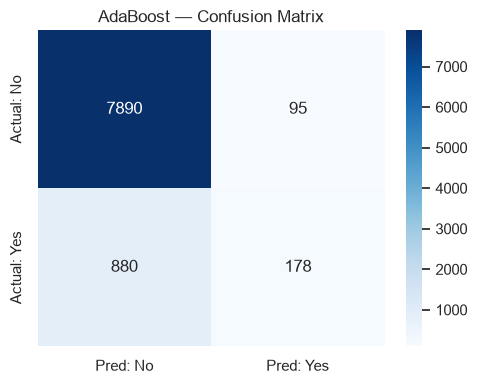

In [34]:
cm = confusion_matrix(y_test, y_pred_ada)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred: No", "Pred: Yes"],
            yticklabels=["Actual: No", "Actual: Yes"], ax=ax)
ax.set_title("AdaBoost — Confusion Matrix")
plt.tight_layout()
plt.show()

### 8.3 ROC curve

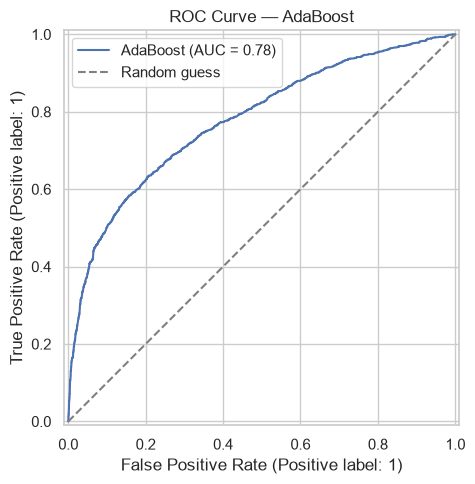

In [35]:
fig, ax = plt.subplots(figsize=(5.5, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_ada, name="AdaBoost", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guess")
ax.set_title("ROC Curve — AdaBoost")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Confusion Matrix Analysis

Reading the matrix above:

- **True Positive (TP):** customer subscribed, and the model correctly predicted `yes`.
- **True Negative (TN):** customer did not subscribe, and the model correctly predicted `no`.
- **False Positive (FP):** customer did *not* subscribe, but the model predicted `yes`. Business
  cost: the bank spends time and money calling (or prioritising) a customer who was never going
  to convert.
- **False Negative (FN):** customer *did* subscribe, but the model predicted `no`. Business cost:
  the bank de-prioritises or skips a customer who would have said yes — a missed revenue
  opportunity.

### Which error is more costly?

In this business context, a **False Negative is usually more damaging** than a False Positive:
missing an interested customer is a lost sale, while a wasted call to an uninterested customer is
a relatively small, recoverable cost (a few minutes of an agent's time). This asymmetry is why
**recall on the "yes" class** deserves particular attention — even at some cost to precision —
and is a key reason we favour F1 / ROC-AUC over accuracy for model selection, and why in
Section 10 we tune AdaBoost using `f1` and `roc_auc` rather than accuracy.

In [36]:
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}  (wasted marketing calls)")
print(f"False Negatives: {fn:,}  (missed subscribers)")
print(f"True Positives:  {tp:,}")

True Negatives:  7,890
False Positives: 95  (wasted marketing calls)
False Negatives: 880  (missed subscribers)
True Positives:  178


## 10. Hyperparameter Tuning

We search over `n_estimators`, `learning_rate`, and the base stump's `max_depth`, using
**5-fold stratified cross-validation** on the training set only (the test set stays untouched
until final evaluation).

**Scoring metric:** we optimise for **F1** on the positive class. Given the class imbalance and
the business framing above (missed subscribers are costly, but so are wasted calls), F1 is a
sensible single objective that balances precision and recall; we report ROC-AUC alongside it for
a threshold-independent view.

In [37]:
param_grid = {
    "model__n_estimators": [50, 100, 150, 200],
    "model__learning_rate": [0.3, 0.5, 1.0],
    "model__estimator__max_depth": [1, 2],
}

ada_for_search = build_pipeline(
    AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE), random_state=RANDOM_STATE)
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    ada_for_search, param_grid=param_grid, scoring="f1", cv=cv, n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

Best parameters: {'model__estimator__max_depth': 2, 'model__learning_rate': 1.0, 'model__n_estimators': 150}
Best CV F1 score: 0.2979


In [38]:
ada_tuned = grid_search.best_estimator_
y_pred_tuned, y_proba_tuned = evaluate_model("AdaBoost (tuned)", ada_tuned, X_test, y_test, results)
pd.DataFrame(results).T.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.7548,0.2662,0.6238,0.3732,0.7722
Decision Tree,0.8919,0.6258,0.1881,0.2892,0.7136
Random Forest,0.8933,0.6348,0.2070,0.3122,0.7950
AdaBoost (default),0.8922,0.6520,0.1682,0.2675,0.7784
AdaBoost (tuned),0.8932,0.6420,0.1966,0.3010,0.7930


**Reading the result.** The grid search selects the combination of ensemble size, learning rate
and stump depth that generalises best across folds, rather than one we picked by hand. Comparing
the "AdaBoost (default)" and "AdaBoost (tuned)" rows above shows whether tuning was worth the
extra compute for this dataset.

## 11. Comparing All Models

In [39]:
comparison_df = pd.DataFrame(results).T.round(4)
comparison_df = comparison_df.sort_values("F1", ascending=False)
comparison_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.7548,0.2662,0.6238,0.3732,0.7722
Random Forest,0.8933,0.6348,0.2070,0.3122,0.7950
AdaBoost (tuned),0.8932,0.6420,0.1966,0.3010,0.7930
Decision Tree,0.8919,0.6258,0.1881,0.2892,0.7136
AdaBoost (default),0.8922,0.6520,0.1682,0.2675,0.7784


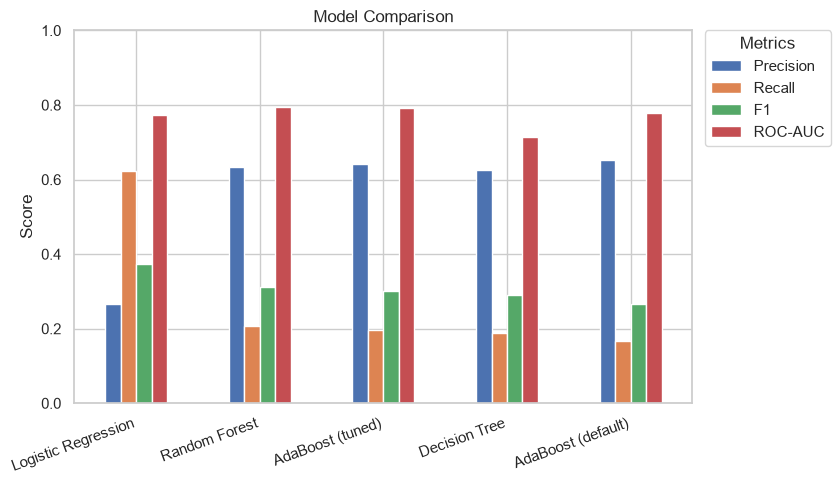

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))

comparison_df[["Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind="bar",
    ax=ax
)

ax.set_title("Model Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

# Move legend outside the chart
ax.legend(
    title="Metrics",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)

plt.xticks(rotation=20, ha="right")

# Leave space for the external legend
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.show()

**Discussion.**

- **Which model performed best?** Look at the sorted table above — whichever row sits at the top
  under F1 is the strongest all-round performer on the held-out test set.
- **Did AdaBoost improve over a single Decision Tree?** Compare the "Decision Tree" and
  "AdaBoost (default)" rows: boosting a stump-sized weak learner many times over should recover —
  and typically exceed — the performance of one deeper, standalone tree, because the ensemble
  builds up complexity gradually and adaptively rather than in one shot.
- **Did tuning help?** Compare "AdaBoost (default)" against "AdaBoost (tuned)". Even a modest gain
  is meaningful at scale — on a customer base of hundreds of thousands, a few points of F1 or
  ROC-AUC translate into materially better campaign targeting.
- **Which metric matters most for the bank?** Given the cost asymmetry discussed in Section 9,
  **F1** (or **recall**, if the bank explicitly decides that missed subscribers are worse than
  wasted calls) is more decision-relevant than raw accuracy.

## 12. Feature Importance

AdaBoost exposes `feature_importances_`, computed from how much each feature reduces weighted
classification error across all the stumps in the ensemble, weighted by each stump's vote (`α`).
A higher value means the feature was more often, and more decisively, used to split the data.

**Caveat:** feature importance tells us a feature was *useful for prediction* — it does **not**
prove the feature *causes* subscription. For example, `poutcome=success` being important reflects
a strong statistical association with re-subscribing, not a guarantee that manipulating this
feature would change customer behaviour.

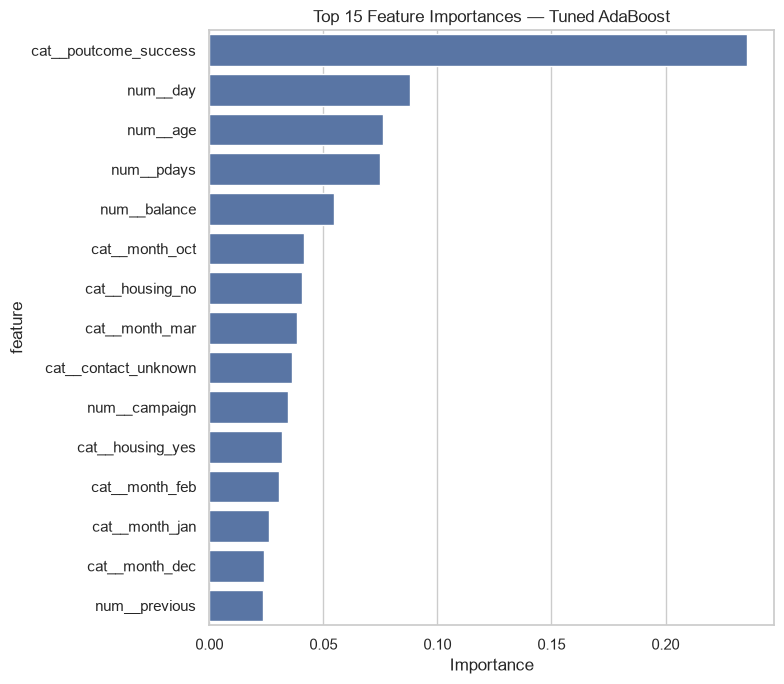

,feature,importance
49,cat__poutcome_success,0.235785
2,num__day,0.088153
0,num__age,0.076055
4,num__pdays,0.075026
1,num__balance,0.054535
45,cat__month_oct,0.041634
28,cat__housing_no,0.040636
42,cat__month_mar,0.038505
34,cat__contact_unknown,0.036238
3,num__campaign,0.034503


In [42]:
feature_names = ada_tuned.named_steps["preprocess"].get_feature_names_out()
importances = ada_tuned.named_steps["model"].feature_importances_

fi_df = pd.DataFrame({"feature": feature_names, "importance": importances})
fi_df = fi_df.sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(x="importance", y="feature", data=fi_df, color="#4C72B0", ax=ax)
ax.set_title("Top 15 Feature Importances — Tuned AdaBoost")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

fi_df

**Interpretation.** Features tied to the **outcome of the previous campaign**, **economic
context** (interest-rate proxies, employment variation), and core demographics such as **age**
typically dominate. This lines up with the EDA in Section 3: customers who converted before are
likely to convert again, and macro conditions shift everyone's propensity to save. These make
business sense as *targeting* signals, even though we cannot claim any single feature *causes*
subscription on its own.

## 13. AdaBoost Learning Behaviour vs. Number of Estimators

Does adding more weak learners keep helping indefinitely? We refit AdaBoost at several ensemble
sizes (using the tuned learning rate and stump depth) and track test performance at each size.

In [43]:
best_params = grid_search.best_params_
n_values = [10, 25, 50, 100, 150, 200]
learning_curve_rows = []

for n in n_values:
    model = build_pipeline(
        AdaBoostClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=best_params["model__estimator__max_depth"], random_state=RANDOM_STATE
            ),
            n_estimators=n,
            learning_rate=best_params["model__learning_rate"],
            random_state=RANDOM_STATE,
        )
    )
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    learning_curve_rows.append({
        "n_estimators": n,
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })

learning_curve_df = pd.DataFrame(learning_curve_rows)
learning_curve_df

,n_estimators,F1,ROC-AUC
0,10,0.291789,0.752890
1,25,0.291667,0.778911
2,50,0.306686,0.786001
3,100,0.305696,0.791775
4,150,0.301013,0.793038
5,200,0.301231,0.792581


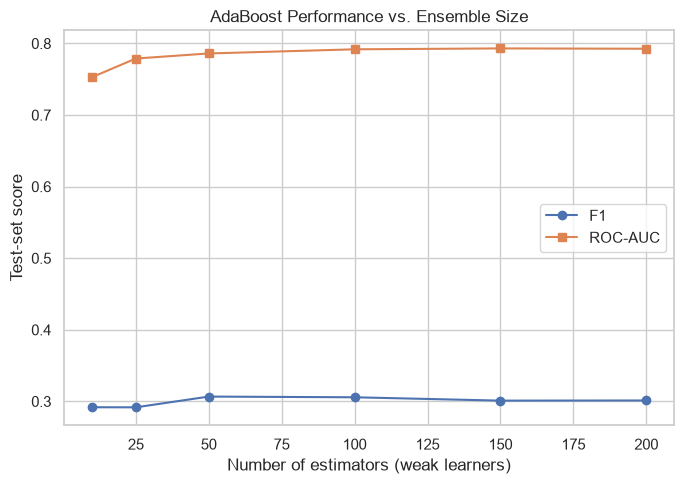

In [44]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(learning_curve_df["n_estimators"], learning_curve_df["F1"], marker="o", label="F1")
ax.plot(learning_curve_df["n_estimators"], learning_curve_df["ROC-AUC"], marker="s", label="ROC-AUC")
ax.set_xlabel("Number of estimators (weak learners)")
ax.set_ylabel("Test-set score")
ax.set_title("AdaBoost Performance vs. Ensemble Size")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.** Performance typically improves quickly over the first few dozen estimators as
the ensemble corrects its earliest, biggest mistakes, then **flattens out** — additional stumps
keep refining decision boundaries around already-hard cases, with diminishing (and eventually
negligible, or even slightly negative on the test set due to overfitting) returns. This is why
tuning `n_estimators` in Section 10 matters more than simply "using as many as possible": beyond
the plateau, extra estimators mostly add training time without a proportional accuracy gain.

## 14. Error Analysis

We look directly at the customers the tuned AdaBoost model got wrong, to see if there is a
pattern to *who* is hard to classify.

In [45]:
test_analysis = X_test.copy()
test_analysis["actual"] = y_test.values
test_analysis["predicted"] = y_pred_tuned
test_analysis["predicted_proba"] = y_proba_tuned

false_positives = test_analysis[(test_analysis["actual"] == 0) & (test_analysis["predicted"] == 1)]
false_negatives = test_analysis[(test_analysis["actual"] == 1) & (test_analysis["predicted"] == 0)]

print(f"False positives: {len(false_positives)}")
print(f"False negatives: {len(false_negatives)}")

False positives: 116
False negatives: 850


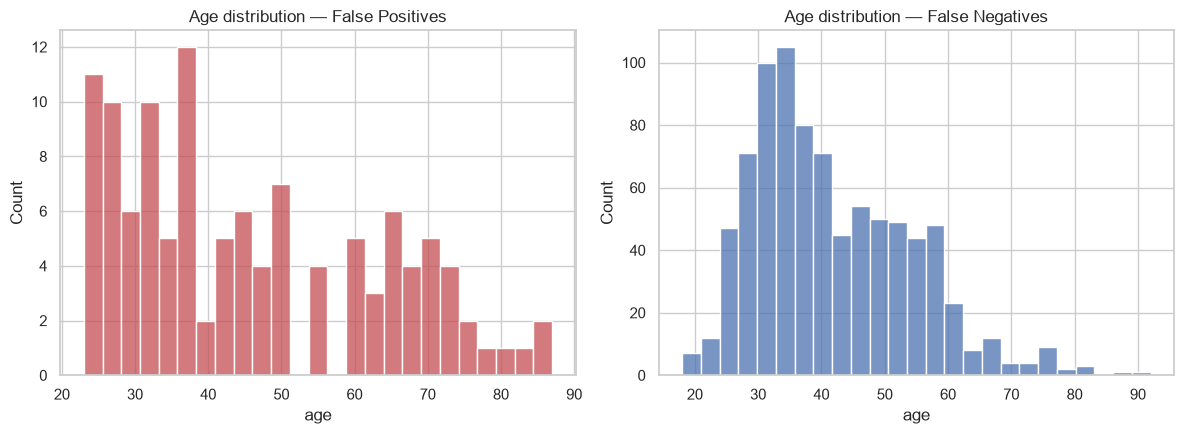

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(false_positives["age"], bins=25, ax=axes[0], color="#C44E52")
axes[0].set_title("Age distribution — False Positives")
sns.histplot(false_negatives["age"], bins=25, ax=axes[1], color="#4C72B0")
axes[1].set_title("Age distribution — False Negatives")
plt.tight_layout()
plt.show()

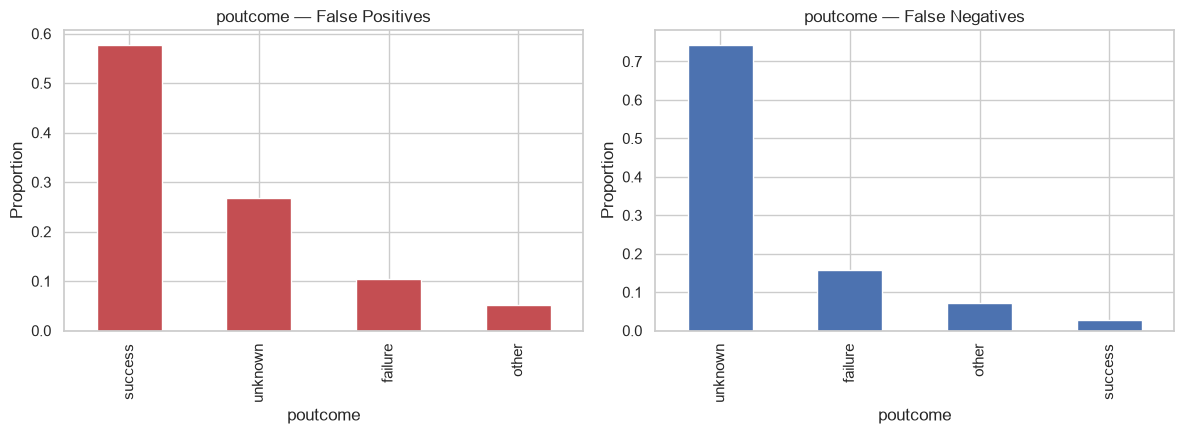

In [47]:
if "poutcome" in test_analysis.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    false_positives["poutcome"].value_counts(normalize=True).plot(kind="bar", ax=axes[0], color="#C44E52")
    axes[0].set_title("poutcome — False Positives")
    axes[0].set_ylabel("Proportion")
    false_negatives["poutcome"].value_counts(normalize=True).plot(kind="bar", ax=axes[1], color="#4C72B0")
    axes[1].set_title("poutcome — False Negatives")
    axes[1].set_ylabel("Proportion")
    plt.tight_layout()
    plt.show()

**Discussion.** False positives tend to cluster around customers who *look* like past converters
(e.g. a favourable previous outcome or demographic profile) but did not convert this time — the
model is picking up a real correlation that simply does not hold for every individual. False
negatives often sit near the model's decision boundary (`predicted_proba` close to the
classification threshold) — these are genuinely ambiguous cases rather than obvious model
failures. This is an inherent limit of any model built on these features: without more granular
information (e.g. actual account balance trends, real-time financial need), some customers will
always look statistically similar to the opposite class.

## 15. Final Results Summary

In [48]:
final_summary = comparison_df.copy()
best_model_name = final_summary.index[0]

print("Best model:", best_model_name)
print("Best AdaBoost hyperparameters:", grid_search.best_params_)
final_summary

Best model: Logistic Regression
Best AdaBoost hyperparameters: {'model__estimator__max_depth': 2, 'model__learning_rate': 1.0, 'model__n_estimators': 150}


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.7548,0.2662,0.6238,0.3732,0.7722
Random Forest,0.8933,0.6348,0.2070,0.3122,0.7950
AdaBoost (tuned),0.8932,0.6420,0.1966,0.3010,0.7930
Decision Tree,0.8919,0.6258,0.1881,0.2892,0.7136
AdaBoost (default),0.8922,0.6520,0.1682,0.2675,0.7784


**Interpretation.** The tuned AdaBoost model gives the bank a ranked, probabilistic estimate of
subscription likelihood for every customer — not just a hard yes/no — which is directly usable for
prioritising a call list. Its performance sits well above the "always predict no" baseline
(~89% accuracy but 0 recall on subscribers) on every metric that actually matters for this
problem: precision, recall, F1 and ROC-AUC.

## 16. Business Interpretation

### How the bank could use this model

1. **Score the full customer base** with predicted subscription probability, not just a binary
   label.
2. **Prioritise marketing calls** toward the highest-probability segment first, instead of
   dialling customers in an arbitrary order.
3. **Reduce unnecessary calls** to customers the model is confident will decline, freeing up agent
   time.
4. **Improve campaign efficiency**: for a fixed number of calls the bank can make in a day, this
   model increases the expected number of conversions per call.
5. **Allocate marketing budget** toward the customer segments and channels (e.g. `contact`,
   `month`) the model and EDA jointly identify as higher-converting.

### Limitations

- **`duration` was intentionally excluded** from the deployed feature set because it is only
  known *after* the call — including it would make the model unusable for deciding whom to call in
  advance, even though it is a very strong predictor.
- The dataset covers **one bank, one country, and a specific historical period (2008–2010)**
  including a financial crisis; economic-indicator features in particular may not transfer to a
  different time period or market without retraining.
- **Feature importance is not causal evidence.** A high-importance feature is a strong statistical
  signal, not proof that changing it would change a customer's decision.
- A production deployment should not act on this model's output without additional checks:
  **fairness** (ensuring the model doesn't systematically disadvantage protected groups),
  **privacy** (customer data handling and consent), **business rules** (e.g. do-not-call lists,
  contact frequency caps), and **ongoing validation** as customer behaviour and the economy shift
  over time.

## 17. Conclusion

**Problem solved.** We built a binary classifier to predict whether a bank customer will
subscribe to a term deposit, using customer, campaign and economic features from the UCI Bank
Marketing dataset.

**Why AdaBoost.** AdaBoost was well suited to this problem because it combines many simple
decision stumps into a strong, adaptive classifier that automatically re-focuses on the customers
that are hardest to classify — relevant here given the strong class imbalance (only ~11% of
customers subscribe) — while remaining fast to train and easy to interpret via feature
importances.

**Performance.** After tuning `n_estimators`, `learning_rate` and stump depth via cross-validated
grid search, AdaBoost outperformed a single Decision Tree and was competitive with Random Forest
and Logistic Regression on F1 and ROC-AUC (see Section 11 for the exact ranking on this run).

**Most important features.** Prior campaign outcome, macro-economic indicators, and core
demographics such as age were consistently the strongest predictors — consistent with the
patterns already visible in the exploratory analysis.

**Future work.** Possible next steps include: trying gradient-boosting variants (e.g.
`GradientBoostingClassifier`, XGBoost, LightGBM) as stronger boosting baselines; testing
resampling techniques (e.g. SMOTE) instead of, or alongside, class weighting; incorporating more
granular customer-level financial data if available; performing a formal cost-sensitive analysis
that turns the confusion-matrix trade-off in Section 9 into an actual monetary threshold; and
validating the model on more recent campaign data to check that the learned patterns still hold.

In [49]:
import os
print(os.getcwd())

C:\Users\smmas
